Loading merged dataset from /kaggle/input/datasets/ibtehajali1/cms-enhanced-dataset/final_merged_dataset.csv...
Running advanced feature engineering...
Starting 5-Fold Patient-Grouped CV on 1,332,755 encounters...
  Fold 1 | ROC-AUC: 0.8599 | PR-AUC: 0.3622
  Fold 2 | ROC-AUC: 0.8594 | PR-AUC: 0.3618
  Fold 3 | ROC-AUC: 0.8599 | PR-AUC: 0.3631
  Fold 4 | ROC-AUC: 0.8591 | PR-AUC: 0.3650
  Fold 5 | ROC-AUC: 0.8581 | PR-AUC: 0.3616

OUT-OF-FOLD PERFORMANCE EVALUATION
Overall ROC-AUC:      0.8593
Overall PR-AUC:       0.3627
Brier Score (Calib):  0.0740

Optimal Threshold: 0.1849 | Max F1-Score: 0.4234
              precision    recall  f1-score   support

           0     0.9581    0.8326    0.8909   1199278
           1     0.3089    0.6726    0.4234    133477

    accuracy                         0.8165   1332755
   macro avg     0.6335    0.7526    0.6572   1332755
weighted avg     0.8931    0.8165    0.8441   1332755



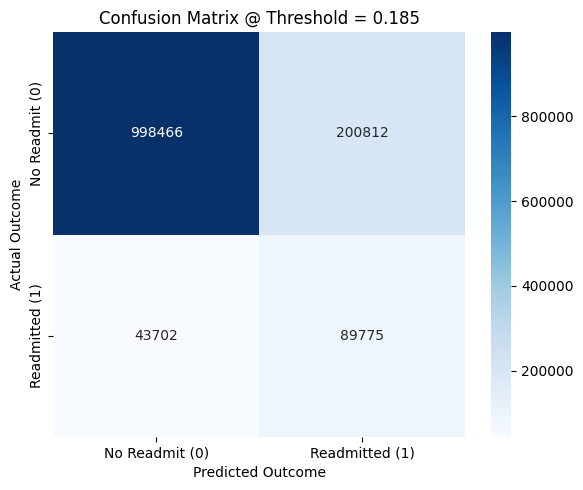


Computing TreeSHAP values for 3,000 sample encounters...


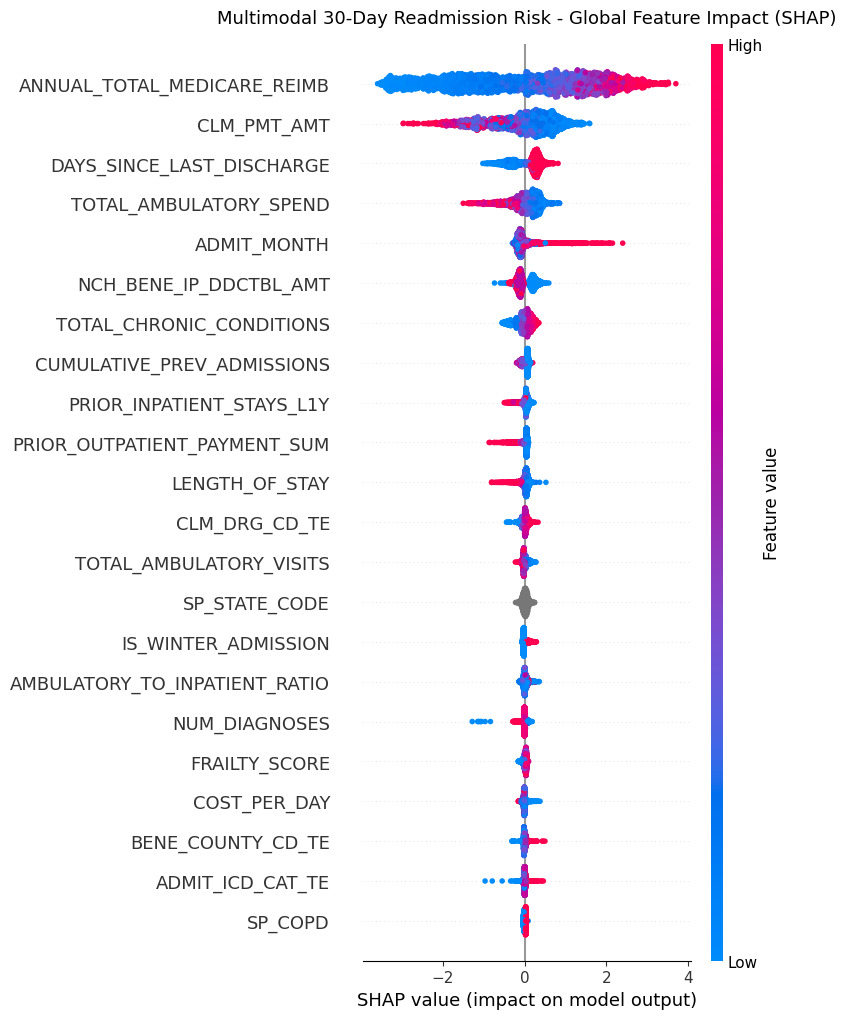

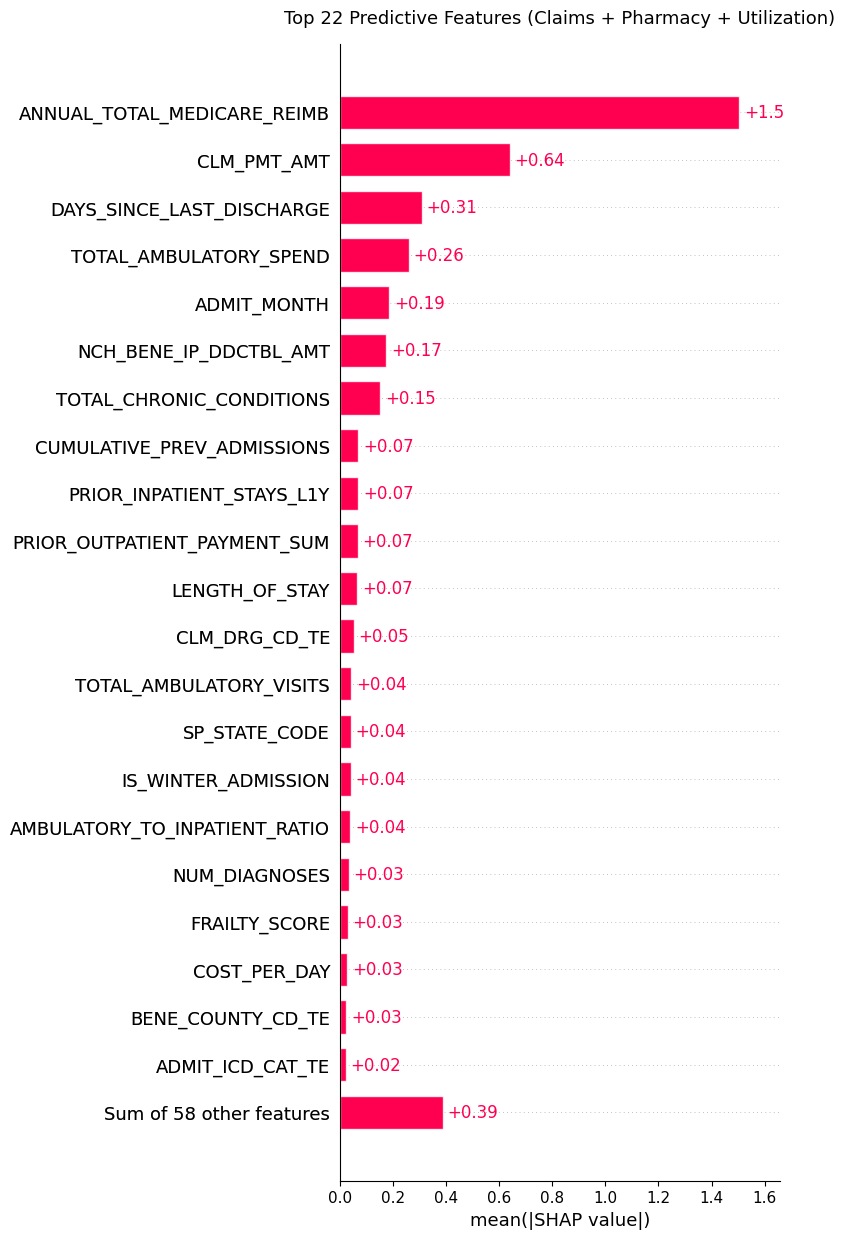

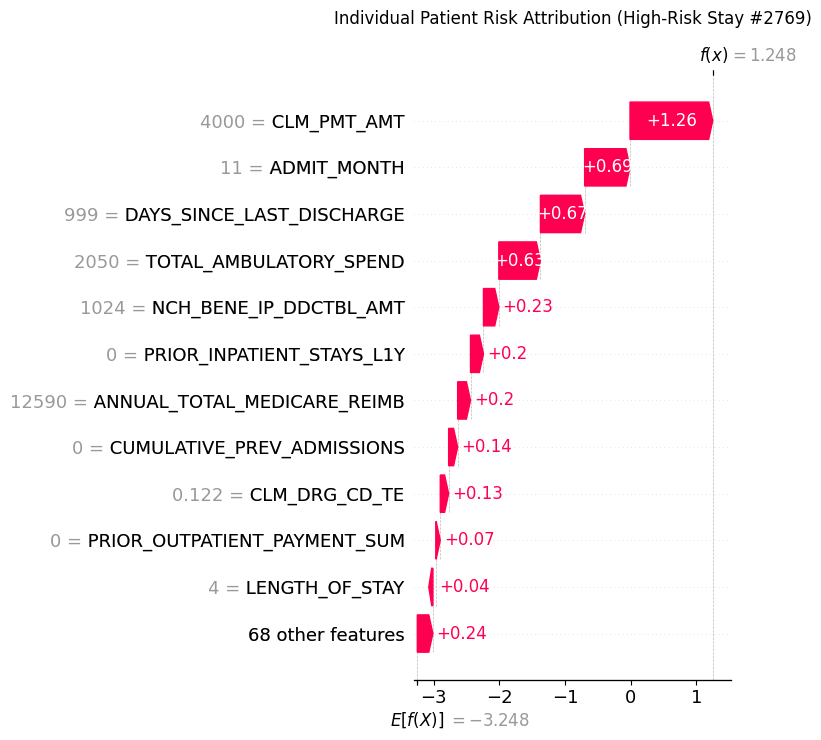

In [1]:
import os
import warnings
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# Configuration & High-Risk Medical Mappings
# -----------------------------------------------------------------------------
DATA_PATH = "/kaggle/input/datasets/ibtehajali1/cms-enhanced-dataset/final_merged_dataset.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "/kaggle/input/datasets/ibtehajali1/cms-data-final/final_merged_dataset.csv"

OUTPUT_DIR = "/kaggle/working/readmission_pipeline_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

HIGH_RISK_DIAGNOSES = {
    "SEPSIS": "038",
    "HEART_FAILURE": "428",
    "ACUTE_RENAL_FAILURE": "584",
    "PNEUMONIA": "486",
    "COPD_FLARE": "491",
    "ELECTROLYTE_DISORDER": "276",
    "AMI": "410",
    "CHRONIC_ISCHEMIC_HD": "414",
    "UTI": "599",
    "STROKE_INFARCT": "434",
    "GI_BLEED": "578",
    "ASPIRATION_PNEUMONIA": "507",
}

HIGH_RISK_PROCEDURES = {
    "HEMODIALYSIS": "3995",
    "BLOOD_TRANSFUSION": "990",
    "VENTILATION_INTUBATION": "967",
    "CARDIAC_CATH": "372",
}


# -----------------------------------------------------------------------------
# 1. Feature Engineering & Preprocessing Module
# -----------------------------------------------------------------------------
def preprocess_and_engineer(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Cleans raw merged CMS data, eliminates data leakage, and engineers

    longitudinal velocity, comorbidity interaction, and utilization features.
    """
    df = df_raw.copy()

    # 1. Parse timestamps and construct temporal lookback trajectory
    if "CLM_ADMSN_DT" in df.columns:
        df["CLM_ADMSN_DT_PARSED"] = pd.to_datetime(
            df["CLM_ADMSN_DT"], errors="coerce"
        )
    if "NCH_BENE_DSCHRG_DT" in df.columns:
        df["NCH_BENE_DSCHRG_DT_PARSED"] = pd.to_datetime(
            df["NCH_BENE_DSCHRG_DT"], errors="coerce"
        )

    if "CLM_ADMSN_DT_PARSED" in df.columns:
        df = df.sort_values(
            by=["DESYNPUF_ID", "CLM_ADMSN_DT_PARSED"]
        ).reset_index(drop=True)
        df["PREV_DSCHRG_DT"] = df.groupby("DESYNPUF_ID")[
            "NCH_BENE_DSCHRG_DT_PARSED"
        ].shift(1)
        df["DAYS_SINCE_LAST_DISCHARGE"] = (
            df["CLM_ADMSN_DT_PARSED"] - df["PREV_DSCHRG_DT"]
        ).dt.days.fillna(999.0)
        df["HAD_PRIOR_READMISSION_90D"] = (
            df["DAYS_SINCE_LAST_DISCHARGE"] <= 90
        ).astype(int)
        df["HAD_PRIOR_READMISSION_30D"] = (
            df["DAYS_SINCE_LAST_DISCHARGE"] <= 30
        ).astype(int)
        df["CUMULATIVE_PREV_ADMISSIONS"] = df.groupby("DESYNPUF_ID").cumcount()

        df["ADMIT_MONTH"] = (
            df["CLM_ADMSN_DT_PARSED"].dt.month.fillna(1).astype(int)
        )
        df["ADMIT_DAY_OF_WEEK"] = (
            df["CLM_ADMSN_DT_PARSED"].dt.dayofweek.fillna(0).astype(int)
        )
        df["IS_WINTER_ADMISSION"] = (
            df["ADMIT_MONTH"].isin([12, 1, 2]).astype(int)
        )
        df["IS_WEEKEND_ADMISSION"] = (
            df["ADMIT_DAY_OF_WEEK"].isin([5, 6]).astype(int)
        )
    else:
        df["DAYS_SINCE_LAST_DISCHARGE"] = 999.0
        df["HAD_PRIOR_READMISSION_90D"] = 0
        df["HAD_PRIOR_READMISSION_30D"] = 0
        df["CUMULATIVE_PREV_ADMISSIONS"] = 0
        df["ADMIT_MONTH"] = 1
        df["ADMIT_DAY_OF_WEEK"] = 0
        df["IS_WINTER_ADMISSION"] = 0
        df["IS_WEEKEND_ADMISSION"] = 0

    # 2. Drop leakage and metadata columns
    leakage_cols = [
        "DAYS_TO_NEXT_ADMISSION",
        "CLM_ID",
        "SOURCE_FILE",
        "CLM_ADMSN_DT",
        "NCH_BENE_DSCHRG_DT",
        "CLM_ADMSN_DT_PARSED",
        "NCH_BENE_DSCHRG_DT_PARSED",
        "PREV_DSCHRG_DT",
    ]
    df = df.drop(columns=[c for c in leakage_cols if c in df.columns], errors="ignore")

    # 3. Clean ESRD and Deductible indicators
    if "BENE_ESRD_IND" in df.columns:
        df["BENE_ESRD_IND"] = (
            df["BENE_ESRD_IND"]
            .astype(str)
            .str.upper()
            .isin(["Y", "1", "1.0"])
            .astype(int)
        )

    df["NCH_BENE_IP_DDCTBL_AMT"] = df["NCH_BENE_IP_DDCTBL_AMT"].fillna(0.0)
    df["IS_ZERO_DEDUCTIBLE"] = (df["NCH_BENE_IP_DDCTBL_AMT"] == 0).astype(int)

    # 4. Multi-diagnosis & procedure complexity counts and binary flags
    diag_cols = [f"ICD9_DGNS_CD_{i}" for i in range(1, 11) if f"ICD9_DGNS_CD_{i}" in df.columns]
    prcdr_cols = [f"ICD9_PRCDR_CD_{i}" for i in range(1, 7) if f"ICD9_PRCDR_CD_{i}" in df.columns]

    df["NUM_DIAGNOSES"] = df[diag_cols].notnull().sum(axis=1) if diag_cols else 0
    df["NUM_PROCEDURES"] = df[prcdr_cols].notnull().sum(axis=1) if prcdr_cols else 0

    for name, prefix in HIGH_RISK_DIAGNOSES.items():
        df[f"FLAG_DX_{name}"] = (
            df[diag_cols]
            .astype(str)
            .apply(lambda col: col.str.strip().str.startswith(prefix))
            .any(axis=1)
            .astype(int)
            if diag_cols
            else 0
        )

    for name, prefix in HIGH_RISK_PROCEDURES.items():
        df[f"FLAG_PX_{name}"] = (
            df[prcdr_cols]
            .astype(str)
            .apply(lambda col: col.str.strip().str.startswith(prefix))
            .any(axis=1)
            .astype(int)
            if prcdr_cols
            else 0
        )

    # 5. Chronic comorbidity burden & geriatric frailty interactions
    chronic_cols = [
        "SP_ALZHDMTA",
        "SP_CHF",
        "SP_CHRNKIDN",
        "SP_CNCR",
        "SP_COPD",
        "SP_DEPRESSN",
        "SP_DIABETES",
        "SP_ISCHMCHT",
        "SP_OSTEOPRS",
        "SP_RA_OA",
        "SP_STRKETIA",
    ]
    for c in chronic_cols:
        if c in df.columns:
            df[c] = df[c].fillna(0).astype(int)

    avail_chronic = [c for c in chronic_cols if c in df.columns]
    df["TOTAL_CHRONIC_CONDITIONS"] = (
        df[avail_chronic].sum(axis=1) if avail_chronic else 0
    )
    df["FRAILTY_SCORE"] = df["TOTAL_CHRONIC_CONDITIONS"] * (
        df["AGE_AT_ADMISSION"].fillna(65.0) / 100.0
    )
    df["IS_VERY_ELDERLY_MULTI_MORBID"] = (
        (df["AGE_AT_ADMISSION"] >= 75) & (df["TOTAL_CHRONIC_CONDITIONS"] >= 5)
    ).astype(int)

    df["INT_CARDIO_RENAL"] = df.get("SP_CHF", 0) * df.get("SP_CHRNKIDN", 0)
    df["INT_CARDIO_PULMONARY"] = df.get("SP_CHF", 0) * df.get("SP_COPD", 0)
    df["INT_DIABETES_RENAL"] = df.get("SP_DIABETES", 0) * df.get("SP_CHRNKIDN", 0)
    df["INT_VASCULAR_STROKE"] = df.get("SP_ISCHMCHT", 0) * df.get("SP_STRKETIA", 0)

    # 6. Pharmacy (Part D) and Polypharmacy Engineering
    df["PRIOR_RX_FILL_COUNT"] = df.get(
        "PRIOR_RX_FILL_COUNT", pd.Series(0, index=df.index)
    ).fillna(0)
    df["PRIOR_RX_COST_SUM"] = df.get(
        "PRIOR_RX_COST_SUM", pd.Series(0, index=df.index)
    ).fillna(0)
    df["PRIOR_RX_DAYS_SUPPLY_SUM"] = df.get(
        "PRIOR_RX_DAYS_SUPPLY_SUM", pd.Series(0, index=df.index)
    ).fillna(0)

    df["POLYPHARMACY_FLAG"] = (df["PRIOR_RX_FILL_COUNT"] >= 15).astype(int)
    df["AVG_COST_PER_RX_FILL"] = df["PRIOR_RX_COST_SUM"] / df[
        "PRIOR_RX_FILL_COUNT"
    ].clip(lower=1)
    df["AVG_DAYS_SUPPLY_PER_FILL"] = df["PRIOR_RX_DAYS_SUPPLY_SUM"] / df[
        "PRIOR_RX_FILL_COUNT"
    ].clip(lower=1)
    df["INT_POLYPHARMACY_FRAILTY"] = (
        df["POLYPHARMACY_FLAG"] * df["FRAILTY_SCORE"]
    )

    # 7. Ambulatory & Outpatient Utilization
    df["PRIOR_CARRIER_CLAIM_COUNT"] = df.get(
        "PRIOR_CARRIER_CLAIM_COUNT", pd.Series(0, index=df.index)
    ).fillna(0)
    df["PRIOR_CARRIER_PAYMENT_SUM"] = df.get(
        "PRIOR_CARRIER_PAYMENT_SUM", pd.Series(0, index=df.index)
    ).fillna(0)
    df["PRIOR_OUTPATIENT_VISIT_COUNT"] = df.get(
        "PRIOR_OUTPATIENT_VISIT_COUNT", pd.Series(0, index=df.index)
    ).fillna(0)
    df["PRIOR_OUTPATIENT_PAYMENT_SUM"] = df.get(
        "PRIOR_OUTPATIENT_PAYMENT_SUM", pd.Series(0, index=df.index)
    ).fillna(0)

    df["TOTAL_AMBULATORY_VISITS"] = (
        df["PRIOR_CARRIER_CLAIM_COUNT"] + df["PRIOR_OUTPATIENT_VISIT_COUNT"]
    )
    df["TOTAL_AMBULATORY_SPEND"] = (
        df["PRIOR_CARRIER_PAYMENT_SUM"] + df["PRIOR_OUTPATIENT_PAYMENT_SUM"]
    )

    # 8. Financial Intensity & Inpatient Utilization Ratios
    df["LENGTH_OF_STAY"] = df["LENGTH_OF_STAY"].clip(lower=1)
    df["COST_PER_DAY"] = df["CLM_PMT_AMT"] / df["LENGTH_OF_STAY"]
    df["RX_TO_INPATIENT_SPEND_RATIO"] = df["PRIOR_RX_COST_SUM"] / (
        df["CLM_PMT_AMT"] + 1.0
    )
    df["AMBULATORY_TO_INPATIENT_RATIO"] = df["TOTAL_AMBULATORY_SPEND"] / (
        df["CLM_PMT_AMT"] + 1.0
    )

    # 9. Extract 3-Digit Category Codes
    df["PRIMARY_ICD_CAT"] = (
        df["ICD9_DGNS_CD_1"].astype(str).str.strip().str[:3].fillna("UNK")
        if "ICD9_DGNS_CD_1" in df.columns
        else "UNK"
    )
    df["ADMIT_ICD_CAT"] = (
        df["ADMTNG_ICD9_DGNS_CD"].astype(str).str.strip().str[:3].fillna("UNK")
        if "ADMTNG_ICD9_DGNS_CD" in df.columns
        else "UNK"
    )

    df = df.drop(
        columns=["ADMTNG_ICD9_DGNS_CD"] + diag_cols + prcdr_cols,
        errors="ignore",
    )
    return df


# -----------------------------------------------------------------------------
# 2. Out-of-Fold Target Encoding
# -----------------------------------------------------------------------------
def apply_target_encoding(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    cat_cols: list,
    smoothing: float = 30.0,
):
    """Calculates smoothed empirical Bayes target encoding strictly within each cross-validation fold."""
    global_mean = y_train.mean()
    X_tr_enc, X_va_enc = X_train.copy(), X_val.copy()

    for col in cat_cols:
        stats = y_train.groupby(X_train[col]).agg(["count", "mean"])
        smoothed = (stats["count"] * stats["mean"] + smoothing * global_mean) / (
            stats["count"] + smoothing
        )

        enc_name = f"{col}_TE"
        X_tr_enc[enc_name] = (
            X_train[col].map(smoothed).fillna(global_mean).astype(float)
        )
        X_va_enc[enc_name] = (
            X_val[col].map(smoothed).fillna(global_mean).astype(float)
        )

        X_tr_enc = X_tr_enc.drop(columns=[col])
        X_va_enc = X_va_enc.drop(columns=[col])

    return X_tr_enc, X_va_enc


# -----------------------------------------------------------------------------
# 3. Model Training & Validation Pipeline
# -----------------------------------------------------------------------------
def train_and_evaluate(df_clean: pd.DataFrame, n_splits: int = 5):
    X = df_clean.drop(columns=["READMITTED_30D", "DESYNPUF_ID"])
    y = df_clean["READMITTED_30D"]
    groups = df_clean["DESYNPUF_ID"]

    # Cast low-cardinality demographic features to category dtype
    for col in ["BENE_SEX_IDENT_CD", "BENE_RACE_CD", "SP_STATE_CODE"]:
        if col in X.columns:
            X[col] = X[col].astype("category")

    target_enc_cols = [
        "CLM_DRG_CD",
        "BENE_COUNTY_CD",
        "PRIMARY_ICD_CAT",
        "ADMIT_ICD_CAT",
    ]

    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    oof_preds = np.zeros(len(df_clean))
    trained_models = []
    val_feature_frames = []

    print(
        f"Starting {n_splits}-Fold Patient-Grouped CV on {len(df_clean):,} encounters..."
    )

    for fold, (t_idx, v_idx) in enumerate(sgkf.split(X, y, groups), 1):
        X_tr, y_tr = X.iloc[t_idx], y.iloc[t_idx]
        X_va, y_va = X.iloc[v_idx], y.iloc[v_idx]

        X_tr_e, X_va_e = apply_target_encoding(
            X_tr, y_tr, X_va, target_enc_cols, smoothing=30.0
        )

        model = lgb.LGBMClassifier(
            n_estimators=1500,
            learning_rate=0.03,
            num_leaves=63,
            max_depth=7,
            min_child_samples=60,
            subsample=0.85,
            colsample_bytree=0.75,
            reg_alpha=2.0,
            reg_lambda=5.0,
            random_state=42 + fold,
            n_jobs=-1,
            verbose=-1,
        )

        model.fit(
            X_tr_e,
            y_tr,
            eval_set=[(X_va_e, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        )

        probs = model.predict_proba(X_va_e)[:, 1]
        oof_preds[v_idx] = probs
        trained_models.append(model)
        val_feature_frames.append(X_va_e)

        fold_roc = roc_auc_score(y_va, probs)
        fold_pr = average_precision_score(y_va, probs)
        print(f"  Fold {fold} | ROC-AUC: {fold_roc:.4f} | PR-AUC: {fold_pr:.4f}")

    # Out-of-fold global metrics
    overall_roc = roc_auc_score(y, oof_preds)
    overall_pr = average_precision_score(y, oof_preds)
    overall_brier = brier_score_loss(y, oof_preds)

    print("\n" + "=" * 55)
    print("OUT-OF-FOLD PERFORMANCE EVALUATION")
    print("=" * 55)
    print(f"Overall ROC-AUC:      {overall_roc:.4f}")
    print(f"Overall PR-AUC:       {overall_pr:.4f}")
    print(f"Brier Score (Calib):  {overall_brier:.4f}")

    # Optimal F1 Decision Threshold Selection
    precisions, recalls, thresholds = precision_recall_curve(y, oof_preds)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(
        f"\nOptimal Threshold: {best_thresh:.4f} | Max F1-Score: {best_f1:.4f}"
    )
    y_pred_optimal = (oof_preds >= best_thresh).astype(int)
    print(classification_report(y, y_pred_optimal, digits=4))

    # Confusion matrix plot
    cm = confusion_matrix(y, y_pred_optimal)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Readmit (0)", "Readmitted (1)"],
        yticklabels=["No Readmit (0)", "Readmitted (1)"],
    )
    plt.title(f"Confusion Matrix @ Threshold = {best_thresh:.3f}")
    plt.ylabel("Actual Outcome")
    plt.xlabel("Predicted Outcome")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=300)
    plt.show()

    return trained_models[0], val_feature_frames[0]


# -----------------------------------------------------------------------------
# 4. SHAP Explainability Suite
# -----------------------------------------------------------------------------
def run_shap_analysis(
    model: lgb.LGBMClassifier, X_sample: pd.DataFrame, sample_size: int = 3000
):
    """Generates global summary beeswarm, top feature importance, and local waterfall explanations."""
    print(
        f"\nComputing TreeSHAP values for {sample_size:,} sample encounters..."
    )

    if len(X_sample) > sample_size:
        X_eval = X_sample.sample(n=sample_size, random_state=42)
    else:
        X_eval = X_sample.copy()

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_eval)

    # 1. Global Beeswarm Summary Plot
    plt.figure(figsize=(11, 9))
    shap.summary_plot(shap_values, X_eval, max_display=22, show=False)
    plt.title(
        "Multimodal 30-Day Readmission Risk - Global Feature Impact (SHAP)",
        fontsize=13,
        pad=15,
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shap_global_beeswarm.png"), dpi=300)
    plt.show()

    # 2. Feature Importance Ranking Bar Plot
    plt.figure(figsize=(11, 8))
    shap.plots.bar(shap_values, max_display=22, show=False)
    plt.title(
        "Top 22 Predictive Features (Claims + Pharmacy + Utilization)",
        fontsize=13,
        pad=15,
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shap_feature_bar.png"), dpi=300)
    plt.show()

    # 3. Patient-Level Waterfall Explanation for High-Risk Case
    high_risk_idx = int(np.argmax(shap_values.values.sum(axis=1)))
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[high_risk_idx], max_display=12, show=False)
    plt.title(
        f"Individual Patient Risk Attribution (High-Risk Stay #{high_risk_idx})",
        fontsize=12,
        pad=15,
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shap_patient_waterfall.png"), dpi=300)
    plt.show()


# -----------------------------------------------------------------------------
# 5. Main Pipeline Execution
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    print(f"Loading merged dataset from {DATA_PATH}...")
    df_raw = (
        pd.read_parquet(DATA_PATH)
        if DATA_PATH.endswith(".parquet")
        else pd.read_csv(DATA_PATH)
    )

    print("Running advanced feature engineering...")
    df_engineered = preprocess_and_engineer(df_raw)

    best_model, X_val_eval = train_and_evaluate(df_engineered, n_splits=5)
    run_shap_analysis(best_model, X_val_eval, sample_size=3000)